# 高级模型优化：XGBoost、LightGBM、CatBoost 与融合

本 notebook 使用已经被验证有效的数据处理方案：移除明显异常点，并对偏态数值特征做 `log1p`。在此基础上比较 XGBoost、LightGBM、CatBoost，以及它们与当前最强线性模型 Lasso 的融合效果。

## 1. 导入依赖与读取数据

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 120)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
SUBMISSION_DIR = ROOT / "submissions"

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

train.shape, test.shape

((1460, 81), (1459, 80))

## 2. 复用当前最佳的数据处理方案

In [2]:
target = "SalePrice"
id_column = "Id"

outlier_mask = (train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)
train_model = train.loc[~outlier_mask].copy()

X = train_model.drop(columns=[target, id_column])
y = train_model[target]
X_test = test.drop(columns=[id_column]).copy()
test_ids = test[id_column]

print("移除异常点数量:", int(outlier_mask.sum()))
print("异常点 Id:", train.loc[outlier_mask, id_column].tolist())

移除异常点数量: 2
异常点 Id: [524, 1299]


In [3]:
def log_transform_skewed_features(X_train: pd.DataFrame, X_test: pd.DataFrame, threshold: float = 0.75):
    X_train = X_train.copy()
    X_test = X_test.copy()

    numeric_columns = X_train.select_dtypes(include="number").columns
    skewness = X_train[numeric_columns].skew().sort_values(ascending=False)
    skewed_columns = skewness[skewness > threshold].index.tolist()

    transformed_columns = []
    for column in skewed_columns:
        min_value = min(X_train[column].min(), X_test[column].min())
        if pd.notna(min_value) and min_value >= 0:
            X_train[column] = np.log1p(X_train[column])
            X_test[column] = np.log1p(X_test[column])
            transformed_columns.append(column)

    return X_train, X_test, transformed_columns


X_log, X_test_log, transformed_columns = log_transform_skewed_features(X, X_test)
print("log1p 处理的列数量:", len(transformed_columns))
transformed_columns

log1p 处理的列数量: 20


['MiscVal',
 'PoolArea',
 'LotArea',
 '3SsnPorch',
 'LowQualFinSF',
 'KitchenAbvGr',
 'BsmtFinSF2',
 'ScreenPorch',
 'BsmtHalfBath',
 'EnclosedPorch',
 'MasVnrArea',
 'OpenPorchSF',
 'WoodDeckSF',
 'LotFrontage',
 'MSSubClass',
 'GrLivArea',
 'BsmtUnfSF',
 '1stFlrSF',
 '2ndFlrSF',
 'BsmtFinSF1']

## 3. 建模工具函数

为保持和前面实验一致，这里仍然用 one-hot 编码处理类别特征，并统一在目标变量上做 `log1p`。

In [4]:
def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_model(base_model, scale_numeric: bool = False) -> TransformedTargetRegressor:
    numeric_features = X_log.select_dtypes(include="number").columns.tolist()
    categorical_features = X_log.select_dtypes(exclude="number").columns.tolist()

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(steps=numeric_steps)
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ]
    )

    return TransformedTargetRegressor(
        regressor=Pipeline(steps=[("preprocessor", preprocessor), ("model", base_model)]),
        func=np.log1p,
        inverse_func=np.expm1,
    )


def rmsle(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_pred = np.maximum(y_pred, 0)
    return float(np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred))))


def cross_validate_single_model(model, X_data: pd.DataFrame, y_data: pd.Series) -> float:
    scores = []
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    for train_idx, valid_idx in cv.split(X_data):
        fold_model = clone(model)
        fold_model.fit(X_data.iloc[train_idx], y_data.iloc[train_idx])
        predictions = fold_model.predict(X_data.iloc[valid_idx])
        scores.append(rmsle(y_data.iloc[valid_idx], predictions))

    return float(np.mean(scores))


def cross_validate_ensemble(models: dict[str, TransformedTargetRegressor], X_data: pd.DataFrame, y_data: pd.Series) -> float:
    scores = []
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    for train_idx, valid_idx in cv.split(X_data):
        fold_predictions = []
        for model in models.values():
            fold_model = clone(model)
            fold_model.fit(X_data.iloc[train_idx], y_data.iloc[train_idx])
            fold_predictions.append(fold_model.predict(X_data.iloc[valid_idx]))

        blended_predictions = np.mean(fold_predictions, axis=0)
        scores.append(rmsle(y_data.iloc[valid_idx], blended_predictions))

    return float(np.mean(scores))

## 4. 高级模型对比

In [5]:
models = {
    "lasso": build_model(
        LassoCV(alphas=np.logspace(-4, 0, 40), cv=5, max_iter=30000, random_state=42),
        scale_numeric=True,
    ),
    "xgboost": build_model(
        XGBRegressor(
            n_estimators=900,
            learning_rate=0.03,
            max_depth=3,
            subsample=0.85,
            colsample_bytree=0.75,
            reg_lambda=1.5,
            reg_alpha=0.001,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
        )
    ),
    "lightgbm": build_model(
        LGBMRegressor(
            n_estimators=900,
            learning_rate=0.03,
            num_leaves=31,
            subsample=0.85,
            colsample_bytree=0.75,
            reg_lambda=0.1,
            reg_alpha=0.001,
            random_state=42,
            n_jobs=-1,
            verbose=-1,
        )
    ),
    "catboost": build_model(
        CatBoostRegressor(
            iterations=900,
            learning_rate=0.03,
            depth=4,
            l2_leaf_reg=3,
            loss_function="RMSE",
            random_seed=42,
            verbose=False,
            allow_writing_files=False,
        )
    ),
}

single_scores = []
for name, model in models.items():
    score = cross_validate_single_model(model, X_log, y)
    single_scores.append({"方案": name, "CV_RMSLE": score})

single_score_table = pd.DataFrame(single_scores).sort_values("CV_RMSLE")
single_score_table

,方案,CV_RMSLE
0,lasso,0.109897
3,catboost,0.114361
1,xgboost,0.115511
2,lightgbm,0.123736


## 5. 融合实验

单个树模型本地验证未必超过 Lasso，但它们的误差模式可能不同。融合通常能减少方差。

In [6]:
ensemble_candidates = {
    "blend_lasso_xgboost": {"lasso": models["lasso"], "xgboost": models["xgboost"]},
    "blend_lasso_lightgbm": {"lasso": models["lasso"], "lightgbm": models["lightgbm"]},
    "blend_lasso_catboost": {"lasso": models["lasso"], "catboost": models["catboost"]},
    "blend_all": models,
}

ensemble_scores = []
for name, model_group in ensemble_candidates.items():
    score = cross_validate_ensemble(model_group, X_log, y)
    ensemble_scores.append({"方案": name, "CV_RMSLE": score})

ensemble_score_table = pd.DataFrame(ensemble_scores).sort_values("CV_RMSLE")
ensemble_score_table

,方案,CV_RMSLE
0,blend_lasso_xgboost,0.107944
2,blend_lasso_catboost,0.108669
3,blend_all,0.110144
1,blend_lasso_lightgbm,0.110287


## 6. 汇总结果

In [7]:
score_table = pd.concat([single_score_table, ensemble_score_table], ignore_index=True).sort_values("CV_RMSLE")
score_table

,方案,CV_RMSLE
4,blend_lasso_xgboost,0.107944
5,blend_lasso_catboost,0.108669
0,lasso,0.109897
6,blend_all,0.110144
7,blend_lasso_lightgbm,0.110287
1,catboost,0.114361
2,xgboost,0.115511
3,lightgbm,0.123736


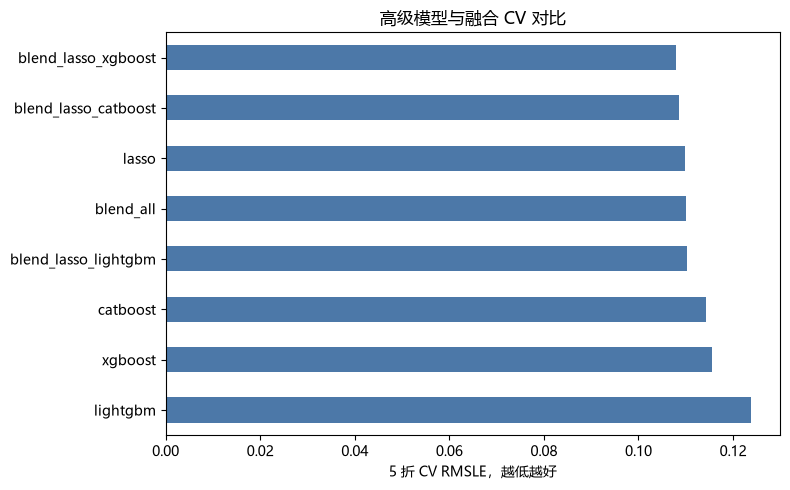

In [8]:
ax = score_table.sort_values("CV_RMSLE", ascending=False).plot(
    kind="barh",
    x="方案",
    y="CV_RMSLE",
    legend=False,
    figsize=(8, 5),
    color="#4C78A8",
)
ax.set_title("高级模型与融合 CV 对比")
ax.set_xlabel("5 折 CV RMSLE，越低越好")
ax.set_ylabel("")
plt.tight_layout()

## 7. 生成最佳融合提交文件

In [9]:
best_name = score_table.iloc[0]["方案"]

if best_name in models:
    selected_models = {best_name: models[best_name]}
else:
    selected_models = ensemble_candidates[best_name]

prediction_list = []
for model in selected_models.values():
    fitted_model = clone(model)
    fitted_model.fit(X_log, y)
    prediction_list.append(fitted_model.predict(X_test_log))

final_predictions = np.maximum(np.mean(prediction_list, axis=0), 0)
submission = pd.DataFrame({"Id": test_ids, "SalePrice": final_predictions})

SUBMISSION_DIR.mkdir(exist_ok=True)
submission_path = SUBMISSION_DIR / "05_submission_boosting_blend.csv"
submission.to_csv(submission_path, index=False)

best_name, submission_path, submission.head(), submission["SalePrice"].describe()

('blend_lasso_xgboost',
 WindowsPath('C:/Users/84740/house-prices-advanced-regression/submissions/05_submission_boosting_blend.csv'),
      Id      SalePrice
 0  1461  120722.803033
 1  1462  154951.123889
 2  1463  183777.315814
 3  1464  196259.888837
 4  1465  190432.693792,
 count      1459.000000
 mean     178596.103694
 std       78724.210216
 min       41110.687726
 25%      126692.948331
 50%      157048.473663
 75%      209627.199420
 max      830047.102386
 Name: SalePrice, dtype: float64)

## 8. 提交命令

```powershell
kaggle competitions submit -c house-prices-advanced-regression-techniques -f submissions/05_submission_boosting_blend.csv -m "lasso xgboost blend"
```

提交后，把公榜分数记录到 `notebooks/99_submission_score_analysis.md`。